In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
from scipy import sparse
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt
import warnings

In [2]:
adata = sc.read("../results/adata/06-doublets.h5ad")


In [3]:
adata

AnnData object with n_obs × n_vars = 33864 × 78334
    obs: 'sample', 'day', 'scdblfinder_score', 'scdblfinder_class'
    layers: 'ambiguous', 'raw_counts', 'soupx', 'soupx_rounded', 'spliced', 'unspliced'

In [4]:
original_cell_number = adata.n_obs
original_gene_number = adata.n_vars

#### Use rounded soupx counts

In [5]:
adata.X = adata.layers["soupx_rounded"]

#### Cells per Day

In [6]:
adata.obs["day"].value_counts()

day
5    14392
7     7805
0     5895
2     5772
Name: count, dtype: int64

#### Cells per Sample

In [7]:
adata.obs["sample"].value_counts()

sample
D5_C    5467
D5_B    4754
D7_C    4414
D5_A    4171
D2_C    3824
D0_B    3608
D7_D    3391
D0_A    2287
D2_D    1948
Name: count, dtype: int64

---
# Gene Annotation

#### Annotate mitochondrial genes

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")

In [9]:
adata.var["mt"].value_counts()

mt
False    78297
True        37
Name: count, dtype: int64

#### Annotate ribosomal genes

In [10]:
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

In [11]:
adata.var["ribo"].value_counts()

ribo
False    77904
True       430
Name: count, dtype: int64

#### Annotate hemoglobin genes

In [12]:
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(P)]")

In [13]:
adata.var["hb"].value_counts()

hb
False    78317
True        17
Name: count, dtype: int64

---
# Quality metrics for raw data

In [14]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb",], percent_top=[20], inplace=True, log1p=True)

In [15]:
adata

AnnData object with n_obs × n_vars = 33864 × 78334
    obs: 'sample', 'day', 'scdblfinder_score', 'scdblfinder_class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'ambiguous', 'raw_counts', 'soupx', 'soupx_rounded', 'spliced', 'unspliced'

### Malat1 Expression

In [16]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.obs["malat1_expression"] = adata[:, "Malat1"].X.toarray().flatten()

### Intronic Fraction

In [17]:
def get_counts(layer):
    arr = adata.layers[layer]
    return np.asarray(arr.sum(axis=1)).flatten() if sparse.issparse(arr) else arr.sum(axis=1)

spliced = get_counts('spliced')
unspliced = get_counts('unspliced')

total = spliced + unspliced

# avoid divide-by-zero for empty cells
adata.obs['intronic_fraction'] = np.divide(
    unspliced, total, out=np.zeros_like(total, dtype=float), where=total > 0
)

#### Minimum total count

In [18]:
int(adata.obs["total_counts"].min())

527

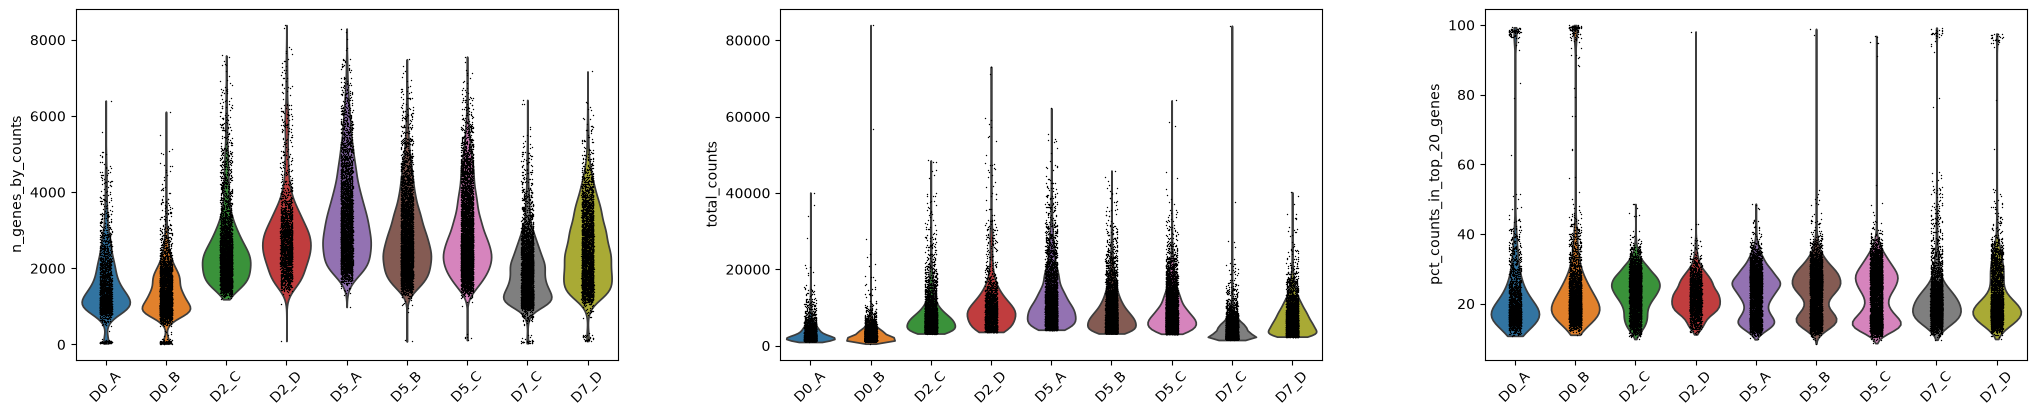

In [19]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_in_top_20_genes"], groupby="sample", rotation=45)

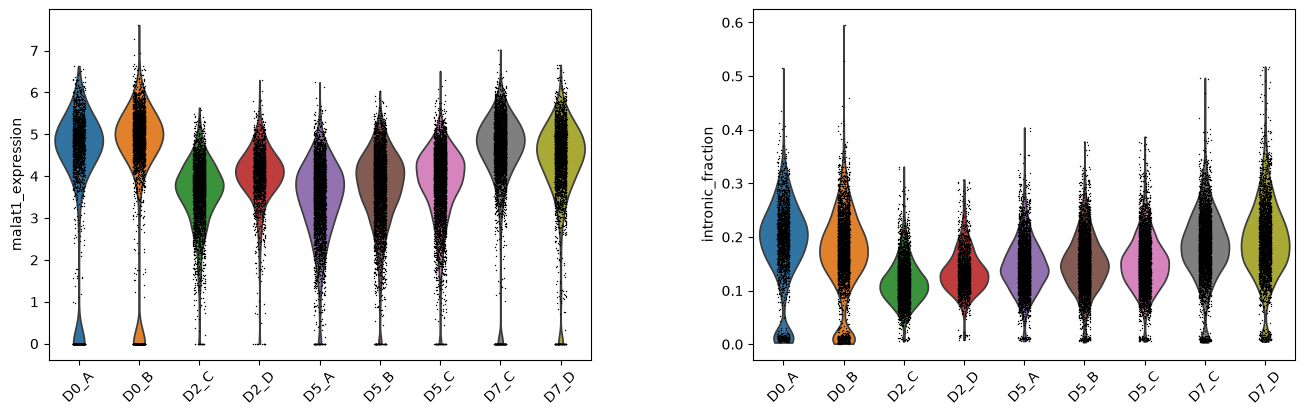

In [20]:
sc.pl.violin(adata, ["malat1_expression", "intronic_fraction"], groupby="sample", rotation=45)

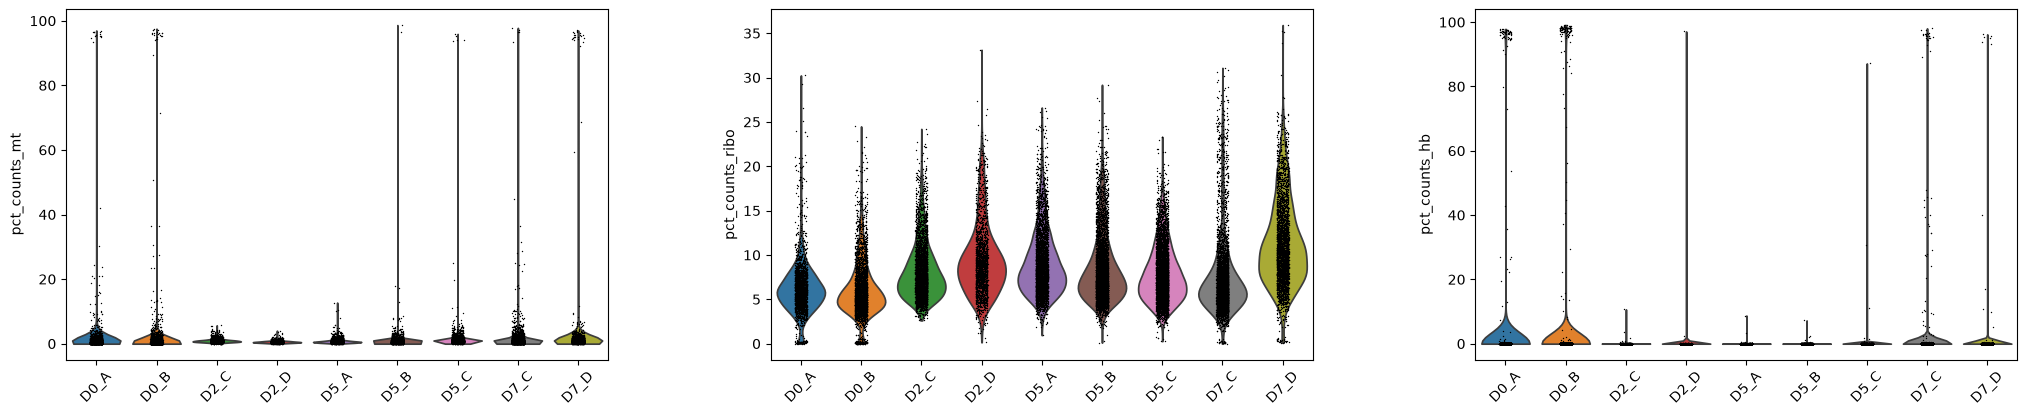

In [21]:
sc.pl.violin(adata, ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],groupby="sample", rotation=45)

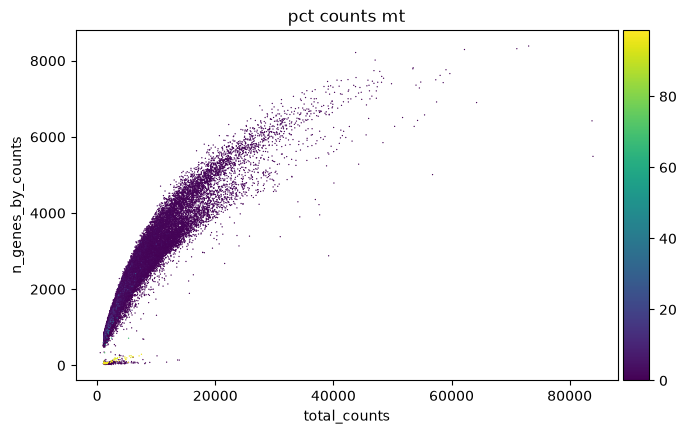

In [22]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

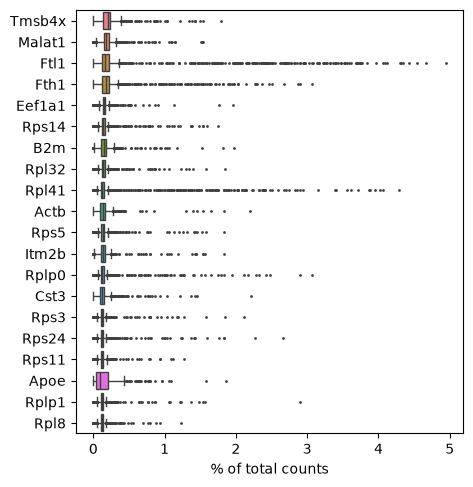

In [23]:
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

sc.pl.highest_expr_genes(adata, n_top=20)

warnings.resetwarnings()

---
# Filtering

## Filter cells with low number of genes

In [24]:
print(f"Number of cells before filtering: {original_cell_number}")
sc.pp.filter_cells(adata, min_genes=500)
print(f"Number of cells after filtering: {adata.n_obs}")

Number of cells before filtering: 33864
Number of cells after filtering: 33591


## Function to compute median absolute deviation outliers

In [25]:
def is_outlier(adata, metric: str, nmads: int, direction="both"):
    M = adata.obs[metric]
    med = np.median(M)
    mad = median_abs_deviation(M)

    if direction == "high":
        return M > med + nmads * mad
    elif direction == "low":
        return M < med - nmads * mad
    elif direction == "both":
        return (M < med - nmads * mad) | (M > med + nmads * mad)
    else:
        raise ValueError("direction must be 'high', 'low', or 'both'")

In [26]:
def mad_outliers_by_sample(adata, sample_col, metric_col, n_mads, direction="both"):
    """
    Flag MAD-based outliers for a QC metric, computed independently within each sample.

    For each group in `adata.obs[sample_col]`, computes the median and median
    absolute deviation (MAD) of `adata.obs[metric_col]`, then flags cells that
    fall outside `n_mads` MADs from that group's own median.

    Parameters
    ----------
    adata : AnnData
        Annotated data object; metric and sample columns are read from adata.obs.
    sample_col : str
        Column in adata.obs identifying the sample/batch to group by.
    metric_col : str
        Column in adata.obs containing the QC metric to evaluate.
    n_mads : float
        Number of MADs from the median beyond which a value is considered an outlier.
    direction : {"both", "upper", "lower"}, default "both"
        - "both":  flag values below (median - n_mads*MAD) OR above (median + n_mads*MAD)
        - "upper": flag values above (median + n_mads*MAD) only
        - "lower": flag values below (median - n_mads*MAD) only

    Returns
    -------
    pd.Series
        Boolean Series aligned to adata.obs.index, True where the cell is an
        outlier for metric_col relative to its own sample's median/MAD.
    """
    if direction not in ("both", "upper", "lower"):
        raise ValueError(f"direction must be 'both', 'upper', or 'lower', got {direction!r}")

    values = adata.obs[metric_col]
    groups = adata.obs.groupby(sample_col, observed=True)[metric_col]

    median = groups.transform("median")
    mad = groups.transform(lambda x: median_abs_deviation(x, nan_policy="omit"))

    lower_bound = median - n_mads * mad
    upper_bound = median + n_mads * mad

    if direction == "both":
        outlier = (values < lower_bound) | (values > upper_bound)
    elif direction == "upper":
        outlier = values > upper_bound
    else:  # "lower"
        outlier = values < lower_bound

    # If a sample's MAD is 0 don't flag anything
    outlier = outlier & (mad > 0)

    return outlier.reindex(adata.obs.index)

## Identify count outliers
- log1p_total_counts: Log of the total number of counts for a cell
- log1p_n_genes_by_counts: The number of genes with at least 1 count in a cell.
- pct_counts_in_top_20_genes: Cumulative percentage of counts for the 20 most expressed genes

In [27]:
adata.obs["log1p_total_counts_outlier"] =         mad_outliers_by_sample(adata, "sample", "log1p_total_counts", 3)
adata.obs["log1p_n_genes_by_counts_outlier"] =    mad_outliers_by_sample(adata, "sample", "log1p_n_genes_by_counts", 3)
adata.obs["pct_counts_in_top_20_genes_outlier"] = mad_outliers_by_sample(adata, "sample", "pct_counts_in_top_20_genes", 3)
adata.obs["pct_counts_mt_outlier"] =              mad_outliers_by_sample(adata, "sample", "pct_counts_mt", 3)
adata.obs["malat1_expression_outlier"] =          mad_outliers_by_sample(adata, "sample", "malat1_expression", 3)
adata.obs["intronic_fraction_outlier"] =          mad_outliers_by_sample(adata, "sample", "intronic_fraction", 3)

## Set hard hemoglobin gene filter

In [28]:
adata.obs["pct_counts_hb_outlier"] = adata.obs["pct_counts_hb"] > 0.5

## Filter

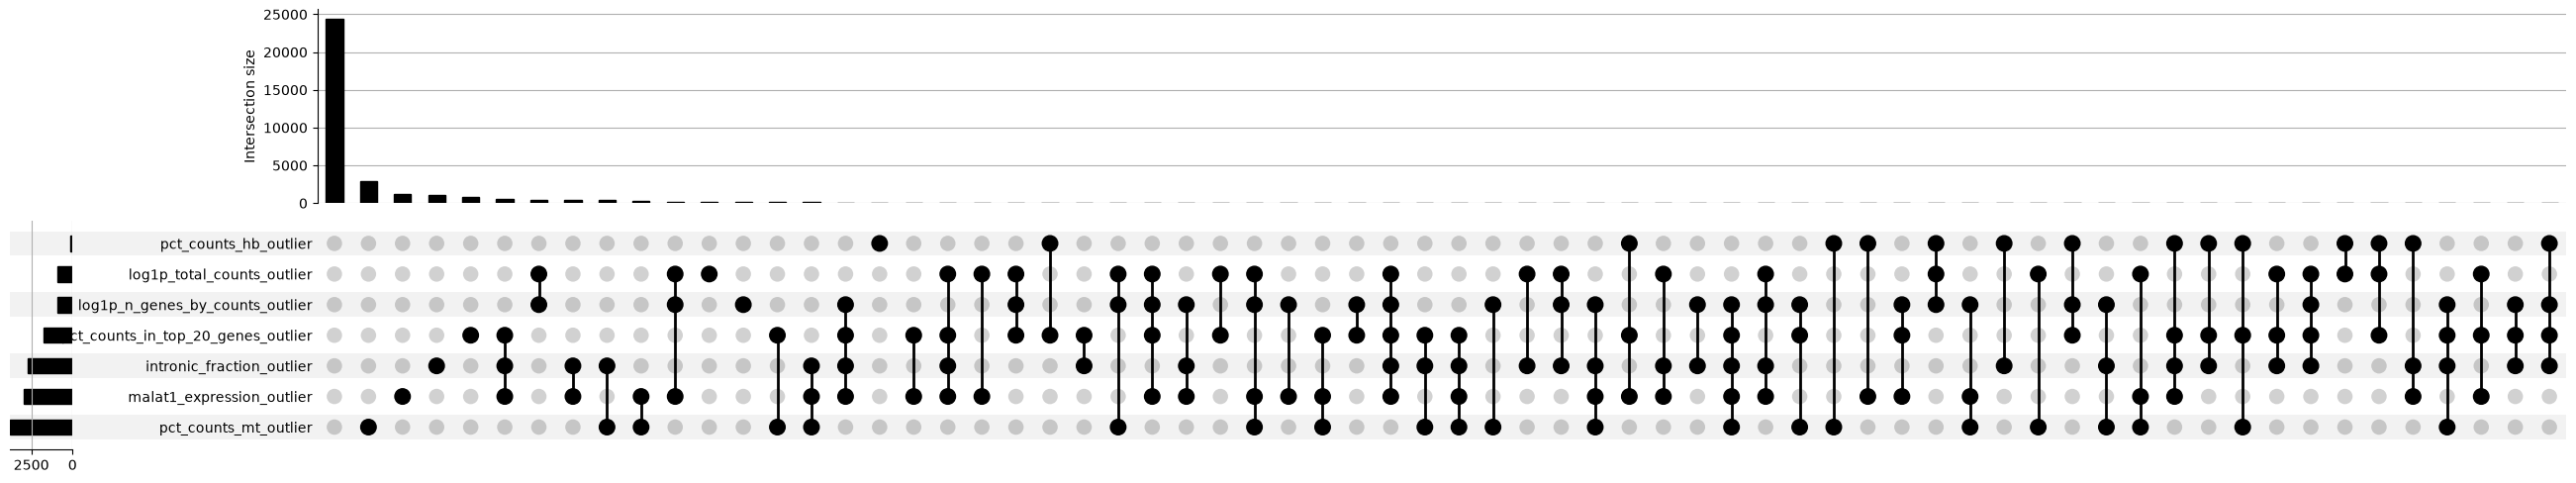

In [29]:
outlier_cols = [
    "log1p_total_counts_outlier",
    "log1p_n_genes_by_counts_outlier",
    "pct_counts_in_top_20_genes_outlier",
    "pct_counts_mt_outlier",
    "malat1_expression_outlier",
    "pct_counts_hb_outlier",
    "intronic_fraction_outlier"
]

warnings.filterwarnings("ignore", category=FutureWarning)

upset_data = from_indicators(outlier_cols, adata.obs[outlier_cols])
UpSet(upset_data, sort_by="cardinality").plot()
plt.show()

warnings.resetwarnings()

In [30]:
# True if any outlier flag is True
outlier_mask = adata.obs[outlier_cols].any(axis=1)

# Keep only non-outliers
adata_filtered = adata[~outlier_mask].copy()

In [31]:
print(f"Original number of cells: {original_cell_number}")
print(f"Number of cells after filtering: {adata_filtered.n_obs}")

print(f"Original number of genes: {original_gene_number}")
print(f"Number of genes after filtering: {adata_filtered.n_vars}")


Original number of cells: 33864
Number of cells after filtering: 24430
Original number of genes: 78334
Number of genes after filtering: 78334


In [32]:
adata_filtered.obs["sample"].value_counts()

sample
D5_C    4234
D5_B    3644
D5_A    3274
D7_C    3162
D2_C    2834
D7_D    2286
D0_B    2146
D2_D    1442
D0_A    1408
Name: count, dtype: int64

## Plot filtered quality metrics

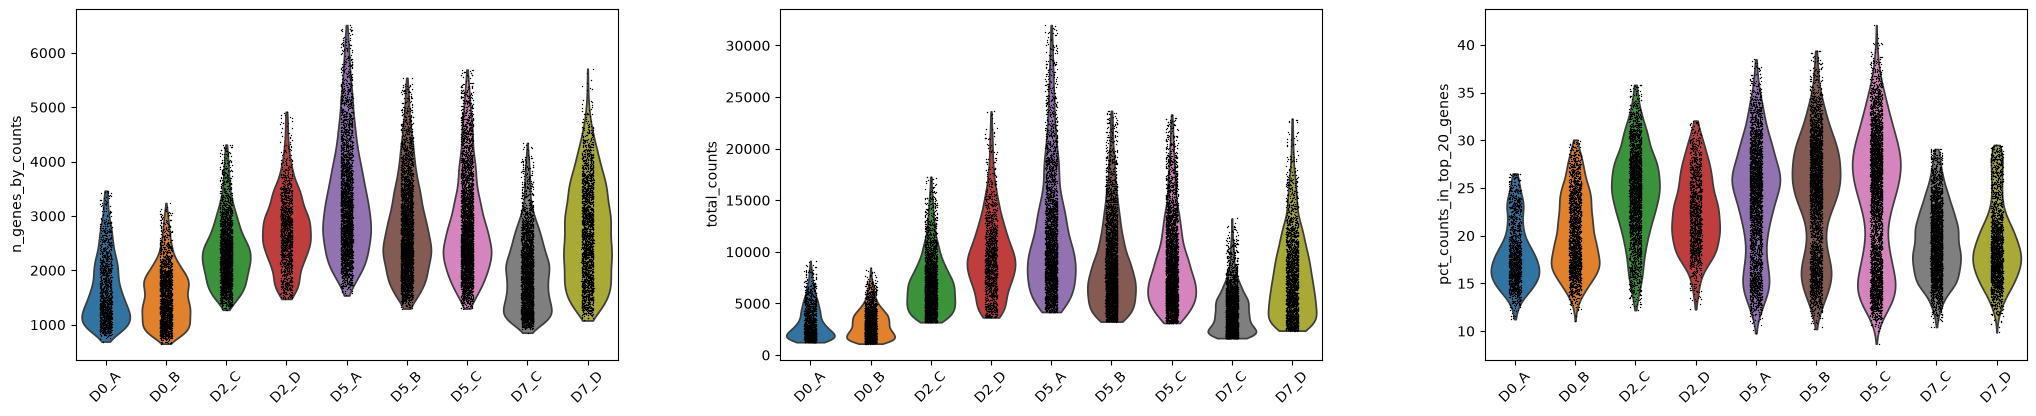

In [33]:
sc.pl.violin(adata_filtered, ["n_genes_by_counts", "total_counts", "pct_counts_in_top_20_genes"], groupby="sample", rotation=45)

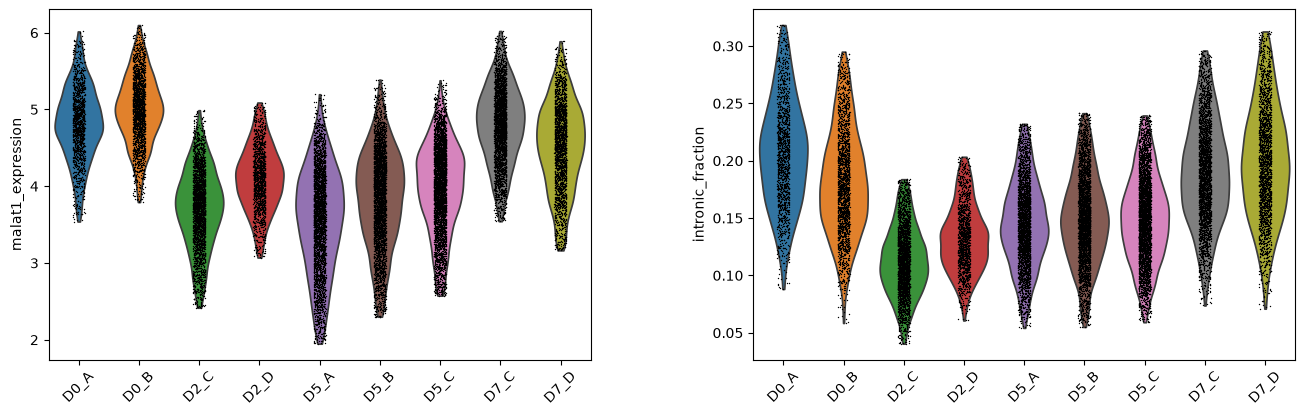

In [34]:
sc.pl.violin(adata_filtered, ["malat1_expression", "intronic_fraction"], groupby="sample", rotation=45)

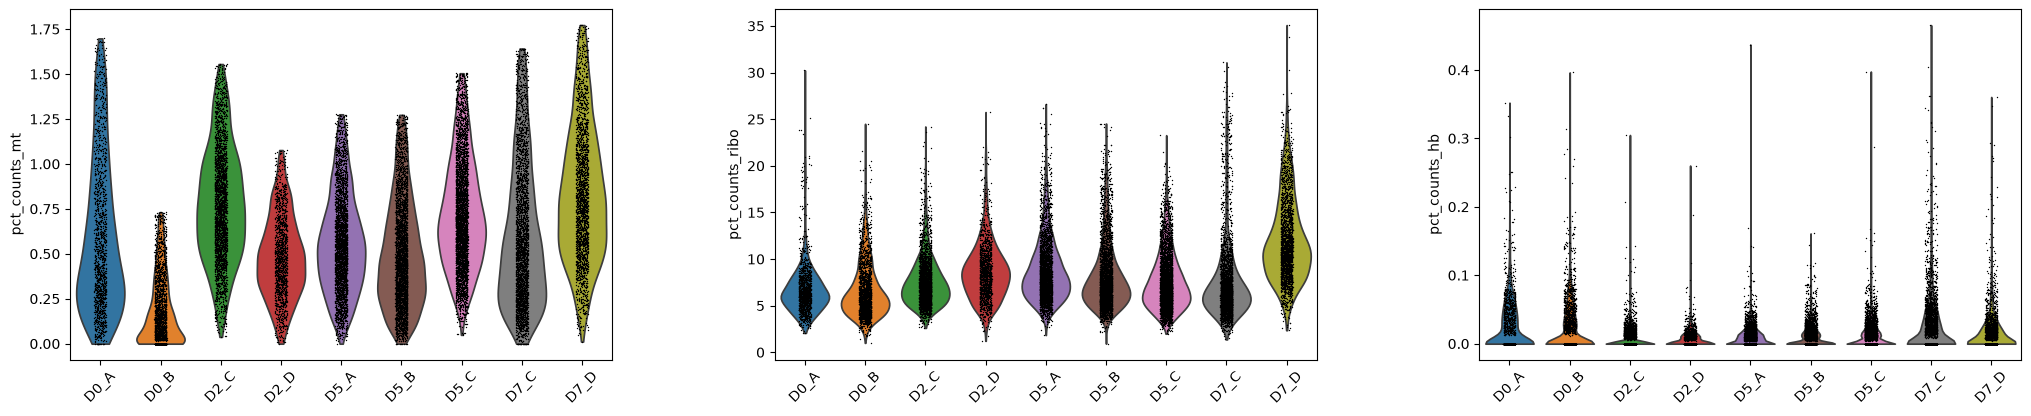

In [35]:
sc.pl.violin(adata_filtered, ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"], groupby="sample", rotation=45)

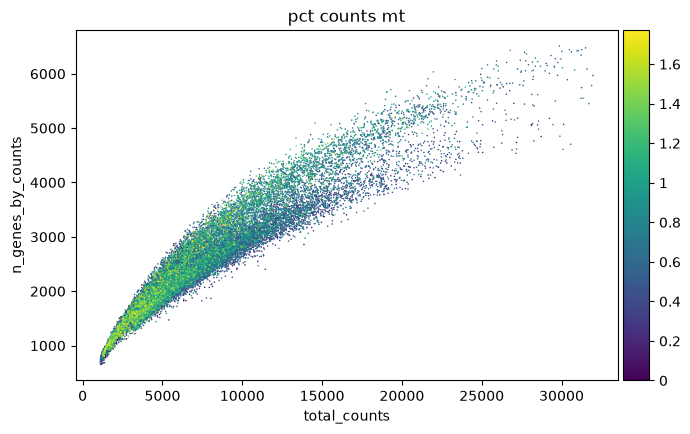

In [36]:
sc.pl.scatter(adata_filtered, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Doublets

In [37]:
adata.obs["scdblfinder_class"].value_counts()

scdblfinder_class
1    31448
2     2143
Name: count, dtype: int64

In [38]:
doublets = adata[adata.obs["scdblfinder_class"] != 1]

### Cells flagged as doublets

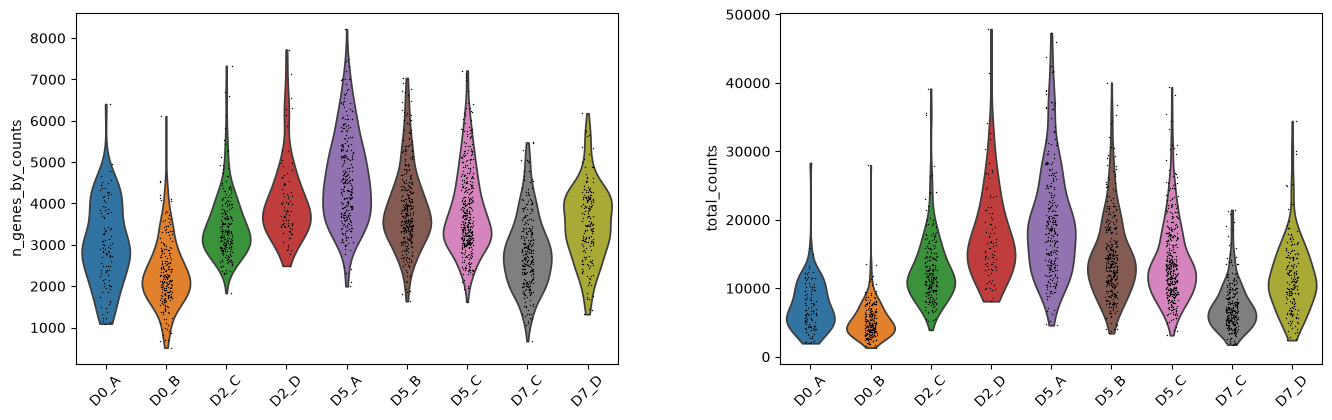

In [39]:
sc.pl.violin(doublets, ["n_genes_by_counts", "total_counts"], groupby="sample", rotation=45)

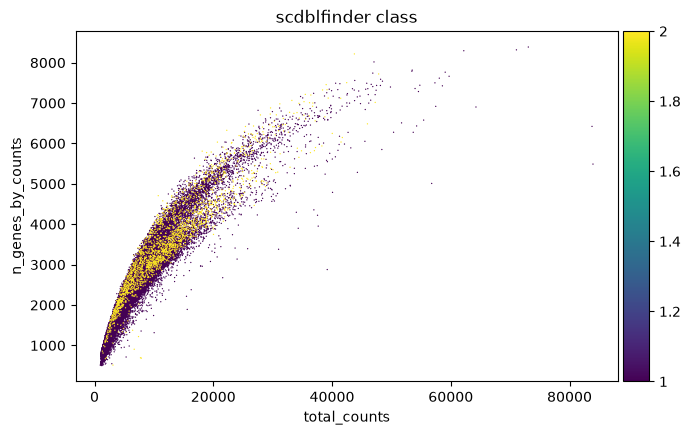

In [40]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="scdblfinder_class"
)

### Filtered

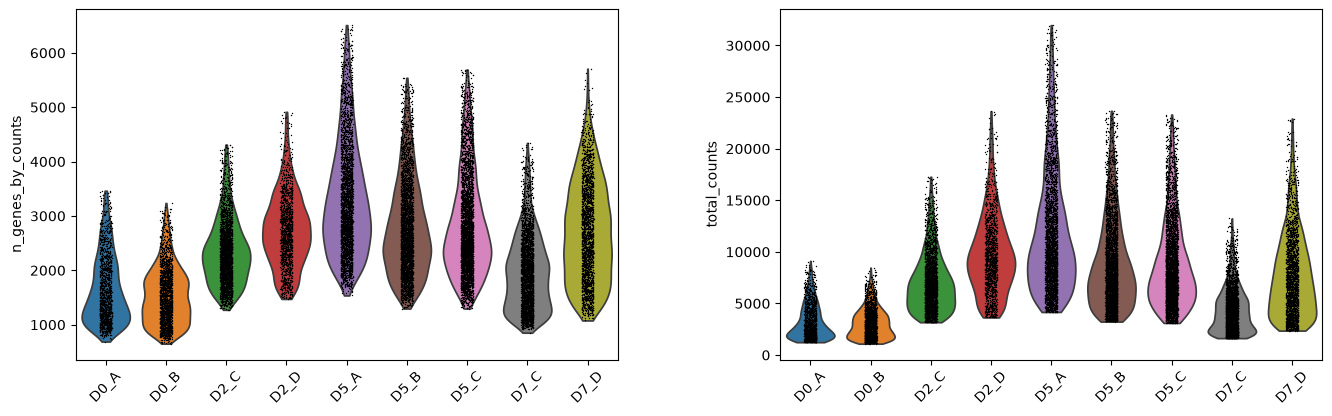

In [41]:
sc.pl.violin(adata_filtered, ["n_genes_by_counts", "total_counts"], groupby="sample", rotation=45)

In [42]:
adata_filtered.write("../results/adata/07-filter.h5ad")